In [ ]:
import pandas as pd
from pathlib import Path


DATA_DIR = Path("../data/raw data")

customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")

print(f"Customers table shape: {customers.shape}")
print(f"Orders table shape: {orders.shape}")
print()
print("Customer columns:", customers.columns.tolist())
print()
print("First 5 customers:")
print(customers.head())


Customers table shape: (99441, 5)
Orders table shape: (99441, 8)

Customer columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

First 5 customers:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4               

In [8]:
tables = {
    "customers":   pd.read_csv(DATA_DIR / "olist_customers_dataset.csv"),
    "orders":      pd.read_csv(DATA_DIR / "olist_orders_dataset.csv"),
    "order_items": pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv"),
    "payments":    pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv"),
    "reviews":     pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv"),
    "products":    pd.read_csv(DATA_DIR / "olist_products_dataset.csv"),
    "sellers":     pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv"),
    "geolocation": pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv"),
    "categories":  pd.read_csv(DATA_DIR / "product_category_name_translation.csv"),
}

print(f"{'Table':<15} {'Rows':>10} {'Cols':>6}")
print("-" * 35)
for name, df in tables.items():
    print(f"{name:<15} {df.shape[0]:>10,} {df.shape[1]:>6}")

Table                 Rows   Cols
-----------------------------------
customers           99,441      5
orders              99,441      8
order_items        112,650      7
payments           103,886      5
reviews             99,224      7
products            32,951      9
sellers              3,095      4
geolocation      1,000,163      5
categories              71      2


In [9]:
for name, df in tables.items():
    print(f"\n{'*'*60}")
    print(f"Table: {name}  |  Shape: {df.shape}")
    print('*'*60)
    df.info(show_counts=True)


************************************************************
Table: customers  |  Shape: (99441, 5)
************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

************************************************************
Table: orders  |  Shape: (99441, 8)
************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                        

In [10]:
# the orders table stores all the dates as strings (saw this in df.info above)
# need to convert them to real datetime so i can do date math later
# (like "days between purchase and delivery" or filter by month)

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

# looping through each column and converting in place
# errors="coerce" -> if pandas can't parse a value (like missing ones for canceled orders),
# it puts NaT instead of crashing. exactly what i want.
for col in date_cols:
    tables["orders"][col] = pd.to_datetime(tables["orders"][col], errors="coerce")

# checking that the dtypes actually changed
print("dtypes after conversion:")
print(tables["orders"].dtypes)
print()

# how much time does the dataset actually cover?
# this matters later when i pick a cutoff date for the churn label
earliest = tables["orders"]["order_purchase_timestamp"].min()
latest = tables["orders"]["order_purchase_timestamp"].max()
span_days = (latest - earliest).days

print(f"earliest purchase: {earliest}")
print(f"latest purchase:   {latest}")
print(f"total time span:   {span_days} days")

dtypes after conversion:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

earliest purchase: 2016-09-04 21:15:19
latest purchase:   2018-10-17 17:30:18
total time span:   772 days


orders per month:
order_purchase_timestamp
2016-09-30       4
2016-10-31     324
2016-11-30       0
2016-12-31       1
2017-01-31     800
2017-02-28    1780
2017-03-31    2682
2017-04-30    2404
2017-05-31    3700
2017-06-30    3245
2017-07-31    4026
2017-08-31    4331
2017-09-30    4285
2017-10-31    4631
2017-11-30    7544
2017-12-31    5673
2018-01-31    7269
2018-02-28    6728
2018-03-31    7211
2018-04-30    6939
2018-05-31    6873
2018-06-30    6167
2018-07-31    6292
2018-08-31    6512
2018-09-30      16
2018-10-31       4
Freq: ME, dtype: int64

total orders: 99,441


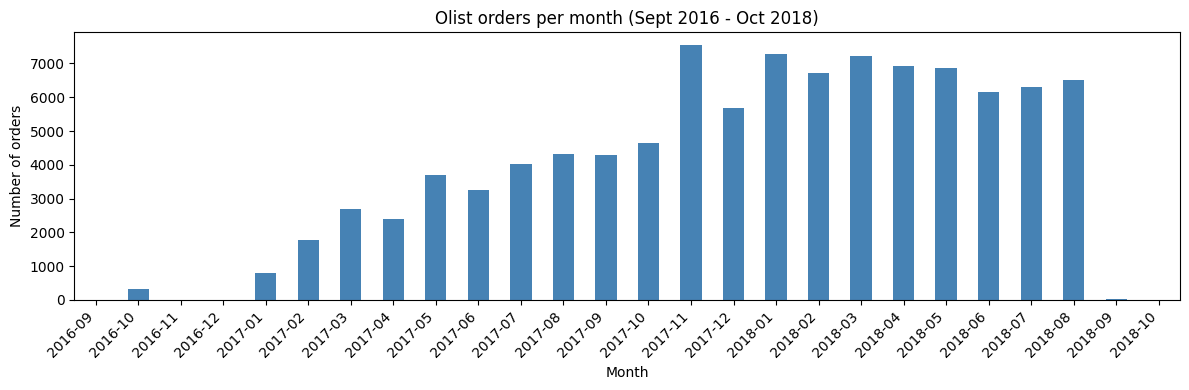

In [11]:
# now that purchase timestamp is a real datetime, i can group orders by month
# this tells me how much data i have in each time period
# important because i'm planning a temporal train/test split later, and i need
# enough orders in both train and test windows

import matplotlib.pyplot as plt

# extracting just the year-month from each purchase timestamp
# .dt.to_period("M") is pandas trick to convert datetimes -> monthly buckets
orders_per_month = (
    tables["orders"]
    .set_index("order_purchase_timestamp")
    .resample("ME")            # ME = month-end frequency
    .size()                    # count rows in each bucket
)

# quick look at the numbers first
print("orders per month:")
print(orders_per_month)
print()
print(f"total orders: {orders_per_month.sum():,}")

# now plot it
fig, ax = plt.subplots(figsize=(12, 4))
orders_per_month.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Olist orders per month (Sept 2016 - Oct 2018)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of orders")
ax.set_xticklabels([d.strftime("%Y-%m") for d in orders_per_month.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# orders have a "status" column - delivered, canceled, etc.
# need to know what values exist and how common each is
# because for churn modeling, i probably only want to count "delivered" orders as real purchases
# (a canceled order isn't really a customer purchase decision worth tracking)

status_counts = tables["orders"]["order_status"].value_counts()
status_pct = tables["orders"]["order_status"].value_counts(normalize=True) * 100

# combining count and percentage in one dataframe so it's easy to read
status_summary = pd.DataFrame({
    "count": status_counts,
    "percent": status_pct.round(2)
})

print("order status distribution:")
print(status_summary)

order status distribution:
              count  percent
order_status                
delivered     96478    97.02
shipped        1107     1.11
canceled        625     0.63
unavailable     609     0.61
invoiced        314     0.32
processing      301     0.30
created           5     0.01
approved          2     0.00


In [13]:
# checking missing values across all 9 tables in one go
# important to know NOW (before feature engineering) which columns
# i can rely on and which i'll need to handle carefully

print(f"{'Table':<15} {'Column':<35} {'Missing':>10} {'Pct':>8}")
print("-" * 70)

for name, df in tables.items():
    # count nulls per column
    nulls = df.isnull().sum()
    # only show columns that actually have missing values
    missing_cols = nulls[nulls > 0]
    
    if len(missing_cols) == 0:
        # nothing to report for this table
        continue
    
    for col, count in missing_cols.items():
        pct = (count / len(df)) * 100
        print(f"{name:<15} {col:<35} {count:>10,} {pct:>7.2f}%")

Table           Column                                 Missing      Pct
----------------------------------------------------------------------
orders          order_approved_at                          160    0.16%
orders          order_delivered_carrier_date             1,783    1.79%
orders          order_delivered_customer_date            2,965    2.98%
reviews         review_comment_title                    87,656   88.34%
reviews         review_comment_message                  58,247   58.70%
products        product_category_name                      610    1.85%
products        product_name_lenght                        610    1.85%
products        product_description_lenght                 610    1.85%
products        product_photos_qty                         610    1.85%
products        product_weight_g                             2    0.01%
products        product_length_cm                            2    0.01%
products        product_height_cm                            2   